In [32]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.init as init

import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.cm as cm
import matplotlib

import ipywidgets as widgets
from IPython.display import display
import trimesh
from torch import autograd as Grad
import random
import math
import pyrender
import time


import open3d as o3d
print('Using open3d version',o3d.__version__)

from utils import *
import differential
import batches_diff_quant


two_pi = 2*torch.pi

Using open3d version 0.18.0


In [33]:
B = pou_blend_func

In [34]:

    
def show_f(f, colors):
    # Assuming target_train is already defined (Shape: [num_triangles, 4330, 3])
    num_triangles = f.shape[0]
    
    # Flatten points and colors to create a single point cloud
    points = f.reshape(-1, 3)  # Shape: e.g. [(80 * 4330), 3]
    colors = colors.reshape(-1, 3)
    
    # Create Open3D PointCloud object
    pcd = o3d.geometry.PointCloud()
    pcd.points = o3d.utility.Vector3dVector(points)   # Assign points
    #pcd.colors = o3d.utility.Vector3dVector(np.random.uniform(size=points_np.shape))   # Assign per-triangle colors
    if not colors is None:
        pcd.colors = o3d.utility.Vector3dVector(colors)   # Assign per-triangle colors
    
    # Visualize the point cloud
    o3d.visualization.draw_geometries([pcd], window_name="Colored 3D Point Cloud")
    o3d.visualization.draw_geometries([pcd, he_mesh], window_name="Colored 3D Point Cloud")

def show_stuff(output):
    colors = np.tile(bary, (output.shape[0], 1))
    show_f(output.detach().numpy(), colors)

    '''
    colors = scalar_field_for_testing['blend'].reshape(-1,3)
    show_f(output_train.detach().numpy(), colors)
    show_f(embedded_triangles.detach().numpy(), colors)
    
    
    colors = np.tile(bary, (target_train.shape[0], 1))
    show_f(embedded_triangles.detach().numpy(), colors)
    show_f(target_train, colors)
    show_f(output_train.detach().numpy(), colors)
    
    
    
    colors = scalar_field_for_testing['angle'].reshape(-1,3)
    show_f(output_train.detach().numpy(), colors)
    show_f(embedded_triangles.detach().numpy(), colors)
    '''
    

class MLP(nn.Module):
    def __init__(self, layer_sizes):
        super(MLP, self).__init__()
        layers = []
        for i in range(len(layer_sizes) - 1):
            linear = nn.Linear(layer_sizes[i], layer_sizes[i + 1])
            #init.zeros_(linear.weight)  # Initialize weights to zero
            #init.zeros_(linear.bias)    # Initialize biases to zero
            layers.append(linear)
            if i < len(layer_sizes) - 2:  # No activation on last layer
                layers.append(nn.Tanh())
        self.network = nn.Sequential(*layers)

    def forward(self, x):
        return self.network(x)




class BlendedMLP(nn.Module):
    def __init__(self, layer_sizes, he_mesh):
        super(BlendedMLP, self).__init__()
        

        #halfedge stuff for the coarse representation
        self.he_mesh = he_mesh
        self.V = torch.tensor(np.asarray(he_mesh.vertices), dtype=torch.float32)
        self.F = np.asarray(he_mesh.triangles)
        self.he = he_mesh.half_edges

        # a vertex assigned to each face can be found using F. use e.g. F[i,0] as the 'special vertex'
        self.V_he = [0 for k in range(self.V.shape[0])] # a halfedge assigned to each vertex (onering)
        for i in range(len(self.he)):
            self.V_he[self.he[i].vertex_indices[0]] =  i

        self.onerings = []
        for i in range(self.V.shape[0]):
            
            onering = {'V_indices':[], 'triangles':[], 'valence':0}
            cur_he = self.he[self.V_he[i]]
            
            vtx_0 = cur_he.vertex_indices[1]
            vtx = vtx_0
            valence = 0
            while (vtx!=vtx_0 or valence==0):
                onering['V_indices'].append(vtx)
                onering['triangles'].append(cur_he.triangle_index)
                cur_he = self.he[ self.he[cur_he.twin].next ]
                vtx = cur_he.vertex_indices[1]
                valence+=1
                
            onering['valence'] = valence
            onering['angle'] = two_pi / valence
            onering['angle_stretch'] = 6 / valence
            self.onerings.append(onering)
        

        self.rotations = [torch.eye(3) for i in range(self.V.shape[0])]
        self.mlps = nn.ModuleList([MLP(layer_sizes) for _ in range(self.V.shape[0])])



        self.base_triangle_verts = torch.tensor([[0.0, 0.0],
                      [1.0, 0.0],
                      [0.5, np.sqrt(3)/2]])



        self.face_onerings = [ [ self.onerings[self.F[triangle_index,i]] for triangle_index in range(self.F.shape[0]) ]
                         for i in range(3) ]


        self.face_angle_vecs = [ torch.tensor([onering['angle'] for onering in self.face_onerings[i]])
                           for i in range(3) ]
        
        self.face_stretch_vecs = [ torch.tensor([onering['angle_stretch'] for onering in self.face_onerings[i]]).unsqueeze(-1)
                             for i in range(3) ] 
        
        self.face_Js = [ torch.tensor( [ self.onerings[self.F[k,i]]['triangles'].index(k) for k in range(self.F.shape[0])] )
                   for i in range(3) ]

        
        
        #self.J = torch.tensor([ [ onering['triangles'].index(triangle_index) if triangle_index in onering['triangles'] else -1 
        #                         for onering in self.onerings]
        #                       for triangle_index in range(self.F.shape[0]) ] )


    def onering_coords(self, x, i, J, angle_vec, stretch_vec):

        ### VEC: make j into J (length 80 vector), and angle and stretch also become length 80 vectors.
        ### these vectors do not change for the whole training process! just compute them at the start.
        ### x is the only thing that changes.
        ### we could precompute pt[I]
        ### we could precompute J*angle
        ### we could precompute I*2*torch.pi/3
    

        v = x-self.base_triangle_verts[i]
        r = torch.sqrt(v.pow(2).sum(-1))
        
        theta = torch.atan2(v[:,1], v[:,0]) 
    
        theta -= i*(two_pi/3) #make it the angle from the relevant edge
    
        theta = theta + (theta<0)*(two_pi) #make sure theta is in [0,2pi)

        #print(theta.shape, stretch_vec.shape, J.shape, angle_vec.shape)
        new_theta = stretch_vec * -1*theta.unsqueeze(0) + (J*angle_vec).unsqueeze(-1)
        #print(new_theta.shape)
        #print ( (J*angle_vec).unsqueeze(-1).shape)
    
        new_theta = new_theta + (new_theta<0)*(two_pi) #make sure theta is in [0,2pi)
        new_theta = new_theta - (new_theta>two_pi)*(two_pi) #make sure theta is in [0,2pi)
        
        onering_x = torch.stack([r*torch.cos(new_theta), r*torch.sin(new_theta)]).transpose(0,1).float().permute(0,2,1)
        return onering_x, r, theta, new_theta

    def save_mlps(self, filename="mlps.pth"):
        torch.save({
        'mlps_state_dict': [mlp.state_dict() for mlp in self.mlps],
        }, filename)

    def load_mlps(self, filename="mlps.pth"):
        checkpoint = torch.load(filename)
    
        for mlp, state_dict in zip(self.mlps, checkpoint['mlps_state_dict']):
            mlp.load_state_dict(state_dict)
        

    def compute_sphere_target(self, x):
        bary = barycentric_coordinates(x[:,0], x[:,1])

        embedded_triangles = []
        for triangle_index in range(self.F.shape[0]):
            verts = self.V[self.F[triangle_index,:]]
            #print(verts)
            embedded_triangles.append ( bary @ verts )
        embedded_triangles = torch.stack(embedded_triangles)

        norms = torch.norm(embedded_triangles, dim=-1, keepdim=True)

        target_shape = embedded_triangles / norms
        return target_shape, embedded_triangles, bary


    def compute_ellipsoid_target(self, x):
        bary = barycentric_coordinates(x[:,0], x[:,1])

        embedded_triangles = []
        for triangle_index in range(self.F.shape[0]):
            verts = self.V[self.F[triangle_index,:]]
            #print(verts)
            embedded_triangles.append ( bary @ verts )
        embedded_triangles = torch.stack(embedded_triangles)

        norms = torch.norm(embedded_triangles, dim=-1, keepdim=True)

        target_shape = (embedded_triangles / norms) * torch.tensor([3.0, 1.0, 2.0]).unsqueeze(0)
        return target_shape, embedded_triangles, bary
            


    
    
    def forward(self, x, zero_test=False):
        time_A = time.time()###############
        
        f = torch.zeros((self.F.shape[0], x.shape[0], 3))
        
        #blendsum = torch.zeros((x.shape[0], 1))
    
        for i in range(3):
            
            ith_onerings = self.face_onerings[i]
            angle_vec = self.face_angle_vecs[i]
            stretch_vec = self.face_stretch_vecs[i]
            J = self.face_Js[i]

            time_X = time.time()#########
            onering_x, r, theta, new_theta = self.onering_coords(x, i, J, angle_vec, stretch_vec)
            time_Y = time.time()#########

            blend = B(r).unsqueeze(-1)

            
            #blendsum += blend
            #print(blend.shape, 'blend shape')
            #vertsum = torch.zeros_like(self.V[0])
            # the crucial part

            time_P=time.time()
            
            for triangle_index in range(self.F.shape[0]):
                vert = self.F[triangle_index,i]
                
                one_onering_x = onering_x[triangle_index,:,:]

                if zero_test==False:
                    f[triangle_index, :, :] +=  blend*( self.mlps[vert](one_onering_x) + self.V[vert] )
                else:
                    f[triangle_index, :, :] +=  blend*( 0*self.mlps[vert](one_onering_x) + self.V[vert] )

            time_Q=time.time()
                    
        time_B = time.time()###############

        #print('fwd:', time_B-time_A, 'onering_coords',time_Y-time_X, 'mlps loop', time_Q-time_P)

        return f
        

In [35]:
tm = trimesh.load('data/surfaces/sphere1_var1.off')
mesh_o3d= o3d.geometry.TriangleMesh()
mesh_o3d.vertices=o3d.utility.Vector3dVector( tm.vertices )
mesh_o3d.triangles=o3d.utility.Vector3iVector( tm.faces)

he_mesh = o3d.geometry.HalfEdgeTriangleMesh.create_from_triangle_mesh(mesh_o3d)
#he_mesh = o3d.geometry.HalfEdgeTriangleMesh.create_from_triangle_mesh(o3d.geometry.TriangleMesh.create_tetrahedron())
#he_mesh = o3d.geometry.HalfEdgeTriangleMesh.create_from_triangle_mesh(o3d.geometry.TriangleMesh.create_icosahedron())
he_mesh = o3d.geometry.HalfEdgeTriangleMesh.create_from_triangle_mesh(o3d.geometry.TriangleMesh.create_octahedron())

# Convert vertices to NumPy, scale, and convert back
#he_mesh.vertices = o3d.utility.Vector3dVector(np.asarray(he_mesh.vertices) * np.array([3.0, 1.0, 2.0]))

In [36]:
#show_stuff()

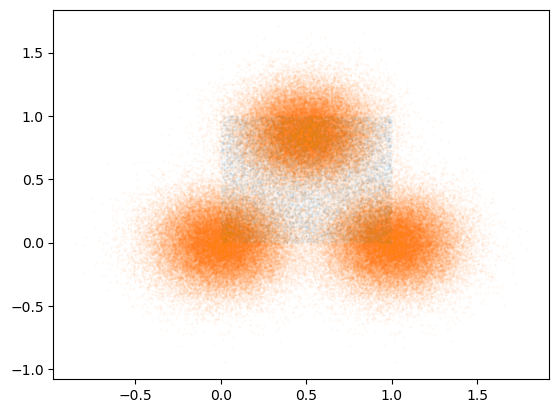

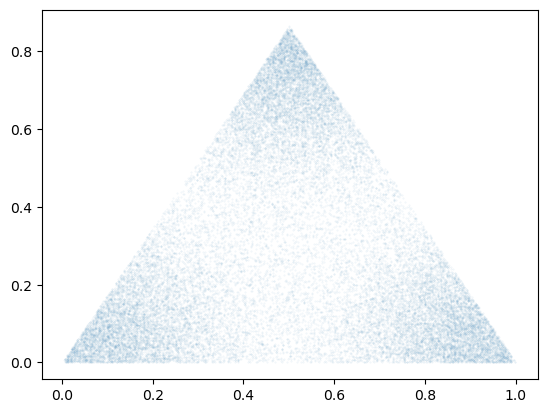

In [37]:
#layer_sizes = [2, 16, 16, 3]
layer_sizes = [2, 8, 8, 3]  # Example structure: 2 input, two hidden layers (16 neurons), 3 output

blended_mlp = BlendedMLP(layer_sizes, he_mesh)


uniform_points = torch.rand(10000, 2)

vertex_points = 0.2 * torch.randn((50000, 2))
vertex_points = torch.cat([vertex_points, vertex_points + torch.tensor([1.0,0.0]), vertex_points + torch.tensor([0.5, np.sqrt(3)/2])]).float()



plt.scatter(uniform_points[:,0], uniform_points[:,1], s=0.1, alpha=0.1)
plt.scatter(vertex_points[:,0], vertex_points[:,1], s=0.1, alpha=0.1)
plt.show()

t_train=torch.cat([uniform_points, vertex_points])

mask = ( t_train[:,1] <= np.sqrt(3)*t_train[:,0] )*( t_train[:,1] <= np.sqrt(3)*(1-t_train[:,0]) ) * (t_train[:,1] >= 0)
t_train = t_train[mask]


plt.scatter(t_train[:,0], t_train[:,1], s=0.1, alpha=0.1)
plt.show()

target_train, embedded_triangles, bary = blended_mlp.compute_sphere_target(t_train)
#target_train, embedded_triangles, bary = blended_mlp.compute_ellipsoid_target(t_train)


In [38]:
#Show the shape with zeroed out MLPs

output_train  = blended_mlp.forward(t_train, zero_test=True)
#show_stuff()


In [39]:
epoch=0
loss=99999
losses=[]
times=[]

Epoch 0, Loss: 0.23433003, Time: 0.057997941970825195


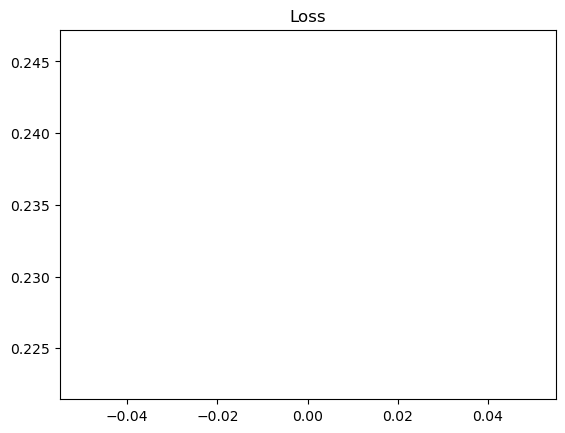

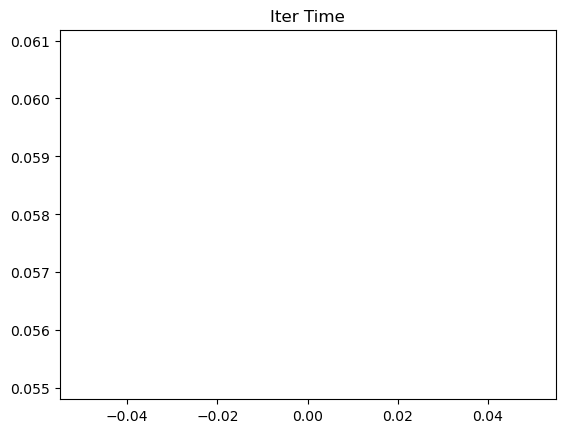

Epoch 10, Loss: 0.18320398, Time: 0.0612332820892334
Epoch 20, Loss: 0.14696717, Time: 0.05815386772155762
Epoch 30, Loss: 0.12241691, Time: 0.058589935302734375
Epoch 40, Loss: 0.10623780, Time: 0.05957818031311035
Epoch 50, Loss: 0.09518955, Time: 0.05718183517456055
Epoch 60, Loss: 0.08696985, Time: 0.05740809440612793
Epoch 70, Loss: 0.08038043, Time: 0.06091475486755371
Epoch 80, Loss: 0.07477837, Time: 0.05764603614807129
Epoch 90, Loss: 0.06968497, Time: 0.06252908706665039
Epoch 100, Loss: 0.06477747, Time: 0.05974292755126953


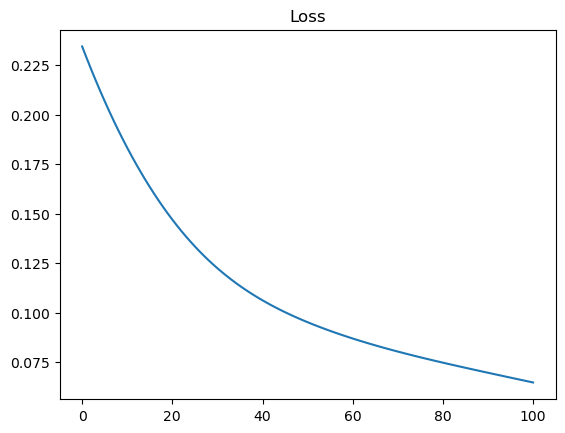

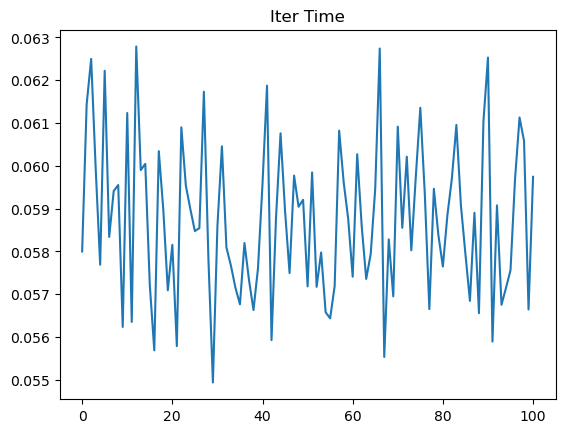

Epoch 110, Loss: 0.05990941, Time: 0.06456398963928223
Epoch 120, Loss: 0.05505483, Time: 0.061777353286743164
Epoch 130, Loss: 0.05024245, Time: 0.06010913848876953
Epoch 140, Loss: 0.04551720, Time: 0.05930805206298828
Epoch 150, Loss: 0.04092568, Time: 0.058985233306884766
Epoch 160, Loss: 0.03651207, Time: 0.06201004981994629
Epoch 170, Loss: 0.03231680, Time: 0.05755496025085449
Epoch 180, Loss: 0.02837594, Time: 0.057089805603027344
Epoch 190, Loss: 0.02472189, Time: 0.05857396125793457
Epoch 200, Loss: 0.02138403, Time: 0.061660051345825195


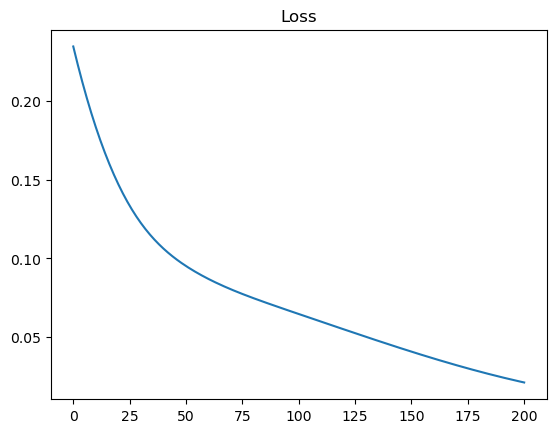

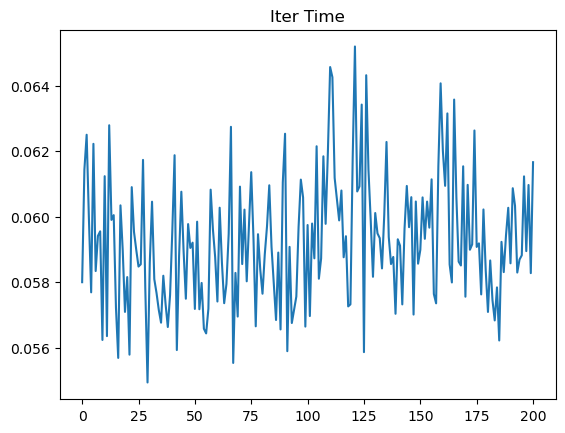

Epoch 210, Loss: 0.01838702, Time: 0.05685710906982422
Epoch 220, Loss: 0.01574684, Time: 0.061249732971191406
Epoch 230, Loss: 0.01346609, Time: 0.0583500862121582
Epoch 240, Loss: 0.01153159, Time: 0.05791306495666504
Epoch 250, Loss: 0.00991588, Time: 0.05521893501281738
Epoch 260, Loss: 0.00858234, Time: 0.06206965446472168
Epoch 270, Loss: 0.00749148, Time: 0.057646989822387695
Epoch 280, Loss: 0.00660578, Time: 0.06007695198059082
Epoch 290, Loss: 0.00589206, Time: 0.0578770637512207
Epoch 300, Loss: 0.00532180, Time: 0.05525612831115723


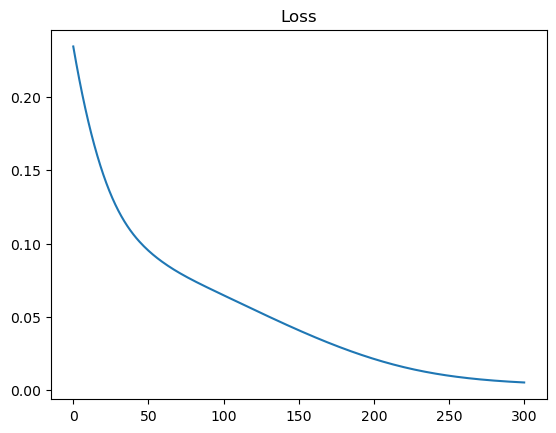

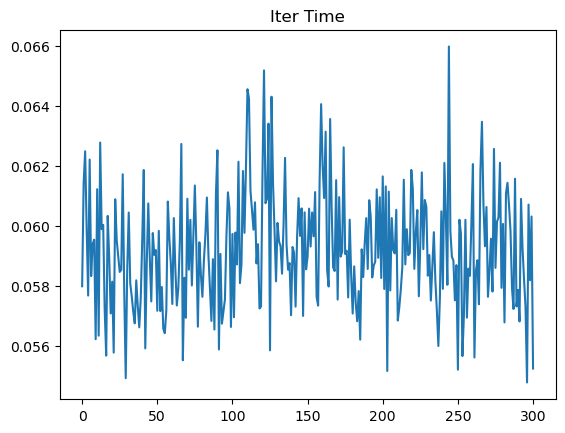

Epoch 310, Loss: 0.00487054, Time: 0.05834197998046875
Epoch 320, Loss: 0.00451709, Time: 0.059797048568725586
Epoch 330, Loss: 0.00424302, Time: 0.05853700637817383
Epoch 340, Loss: 0.00403239, Time: 0.05647706985473633
Epoch 350, Loss: 0.00387168, Time: 0.059552907943725586
Epoch 360, Loss: 0.00374968, Time: 0.061486005783081055
Epoch 370, Loss: 0.00365734, Time: 0.05764198303222656
Epoch 380, Loss: 0.00358752, Time: 0.05741596221923828
Epoch 390, Loss: 0.00353469, Time: 0.05601000785827637
Epoch 400, Loss: 0.00349463, Time: 0.06023073196411133


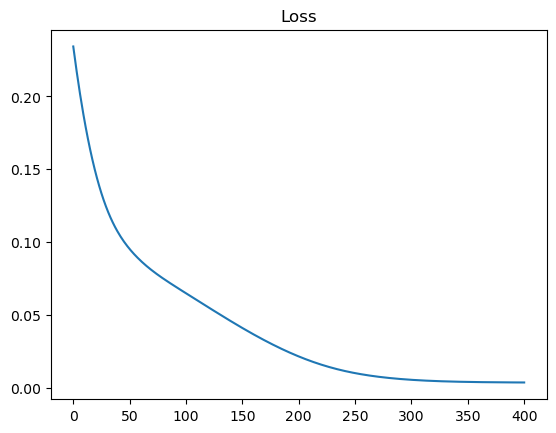

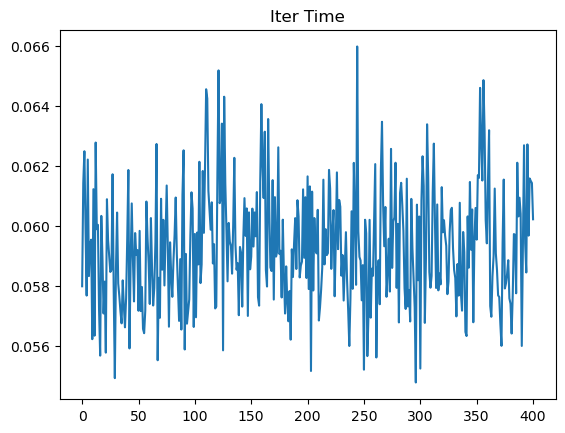

Epoch 410, Loss: 0.00346414, Time: 0.05916094779968262
Epoch 420, Loss: 0.00344081, Time: 0.06226611137390137
Epoch 430, Loss: 0.00342282, Time: 0.057425737380981445
Epoch 440, Loss: 0.00340880, Time: 0.05924510955810547
Epoch 450, Loss: 0.00339774, Time: 0.059137821197509766
Epoch 460, Loss: 0.00338884, Time: 0.05687284469604492
Epoch 470, Loss: 0.00338155, Time: 0.06150388717651367
Epoch 480, Loss: 0.00337541, Time: 0.056899070739746094
Epoch 490, Loss: 0.00337012, Time: 0.06211090087890625
Epoch 500, Loss: 0.00336544, Time: 0.06207704544067383


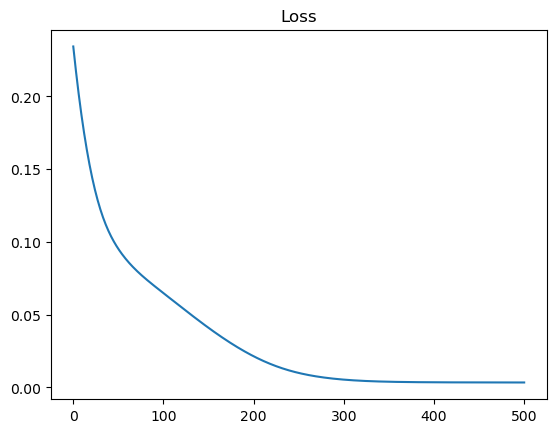

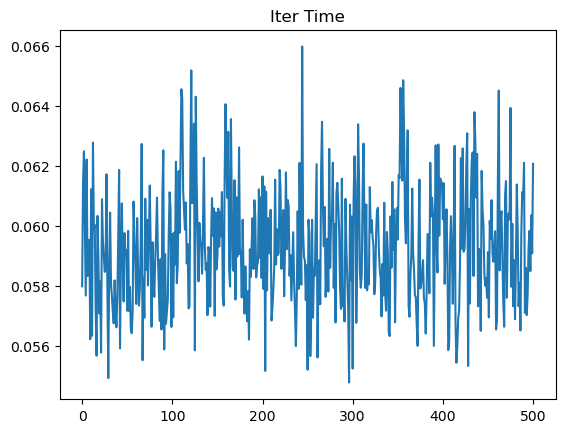

Epoch 510, Loss: 0.00336118, Time: 0.061784982681274414
Epoch 520, Loss: 0.00335724, Time: 0.06118488311767578
Epoch 530, Loss: 0.00335350, Time: 0.06306028366088867
Epoch 540, Loss: 0.00334992, Time: 0.05930972099304199
Epoch 550, Loss: 0.00334644, Time: 0.060417890548706055
Epoch 560, Loss: 0.00334303, Time: 0.06268811225891113
Epoch 570, Loss: 0.00333968, Time: 0.05966305732727051
Epoch 580, Loss: 0.00333635, Time: 0.05913424491882324
Epoch 590, Loss: 0.00333305, Time: 0.05866217613220215
Epoch 600, Loss: 0.00332976, Time: 0.05795097351074219


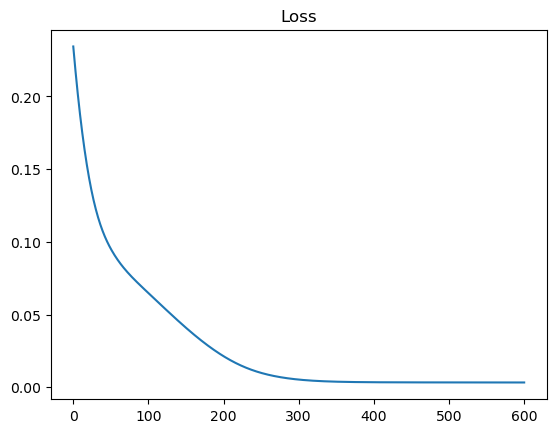

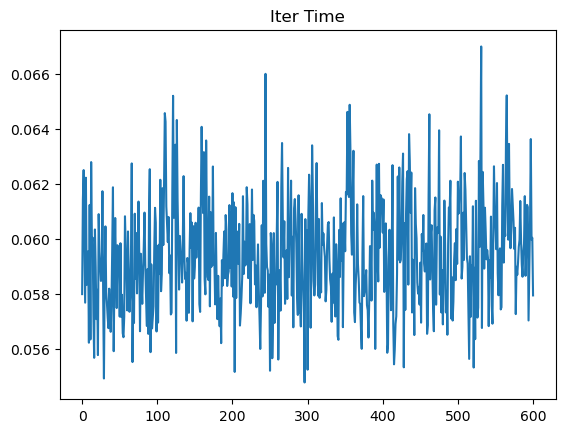

Epoch 610, Loss: 0.00332647, Time: 0.060781002044677734
Epoch 620, Loss: 0.00332320, Time: 0.06100296974182129
Epoch 630, Loss: 0.00331993, Time: 0.059580087661743164
Epoch 640, Loss: 0.00331666, Time: 0.06155896186828613
Epoch 650, Loss: 0.00331339, Time: 0.06186509132385254
Epoch 660, Loss: 0.00331013, Time: 0.060400962829589844
Epoch 670, Loss: 0.00330686, Time: 0.06186509132385254
Epoch 680, Loss: 0.00330360, Time: 0.05771899223327637
Epoch 690, Loss: 0.00330033, Time: 0.06190204620361328
Epoch 700, Loss: 0.00329707, Time: 0.0610041618347168


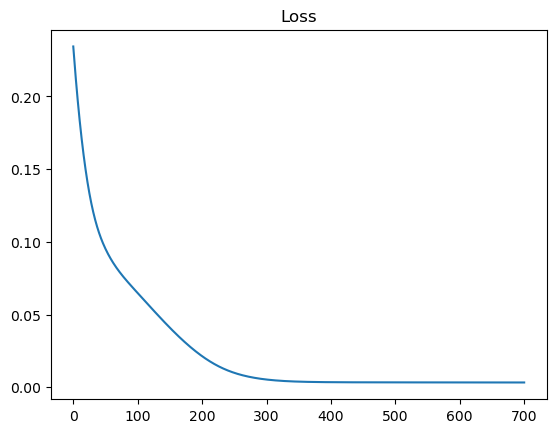

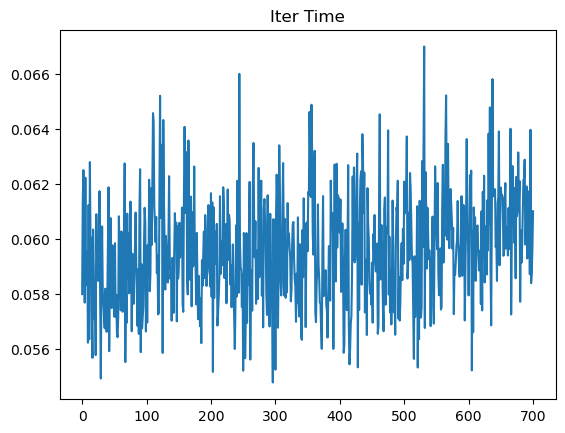

Epoch 710, Loss: 0.00329381, Time: 0.0641622543334961
Epoch 720, Loss: 0.00329056, Time: 0.060790061950683594
Epoch 730, Loss: 0.00328730, Time: 0.06246209144592285
Epoch 740, Loss: 0.00328405, Time: 0.05773115158081055
Epoch 750, Loss: 0.00328079, Time: 0.05916905403137207
Epoch 760, Loss: 0.00327755, Time: 0.06166410446166992
Epoch 770, Loss: 0.00327430, Time: 0.05856728553771973
Epoch 780, Loss: 0.00327106, Time: 0.05942988395690918
Epoch 790, Loss: 0.00326782, Time: 0.06289219856262207
Epoch 800, Loss: 0.00326459, Time: 0.06162405014038086


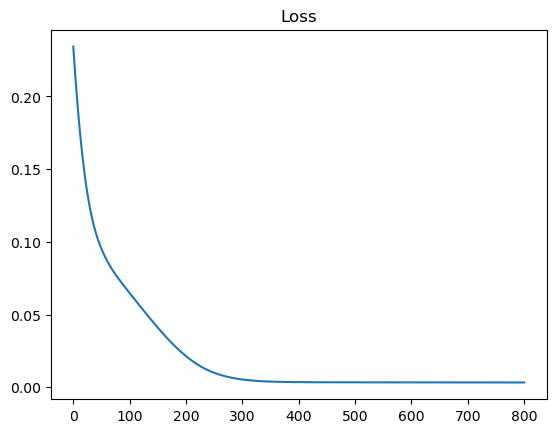

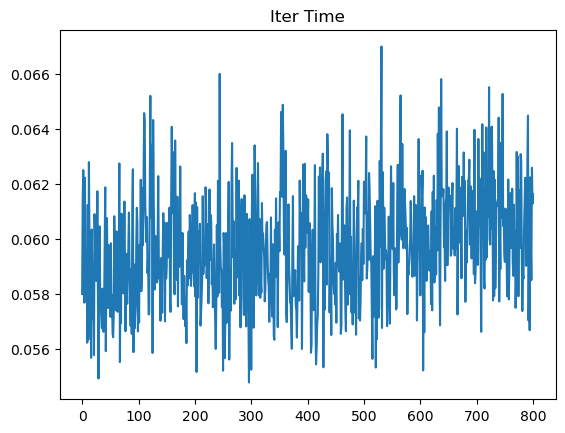

Epoch 810, Loss: 0.00326136, Time: 0.05634021759033203
Epoch 820, Loss: 0.00325814, Time: 0.06100177764892578
Epoch 830, Loss: 0.00325492, Time: 0.0631248950958252
Epoch 840, Loss: 0.00325170, Time: 0.062304019927978516
Epoch 850, Loss: 0.00324849, Time: 0.059500932693481445
Epoch 860, Loss: 0.00324529, Time: 0.05911993980407715
Epoch 870, Loss: 0.00324209, Time: 0.05547690391540527
Epoch 880, Loss: 0.00323890, Time: 0.05701017379760742
Epoch 890, Loss: 0.00323571, Time: 0.06352615356445312
Epoch 900, Loss: 0.00323253, Time: 0.0618281364440918


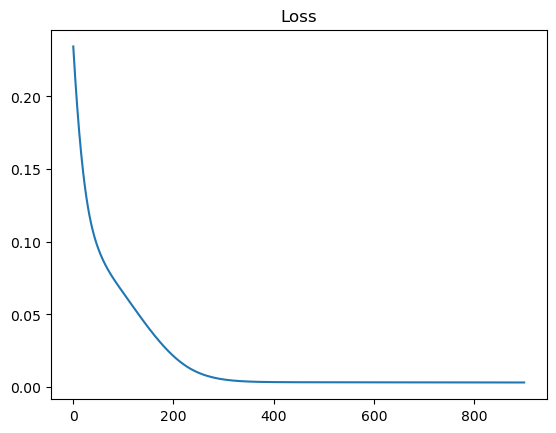

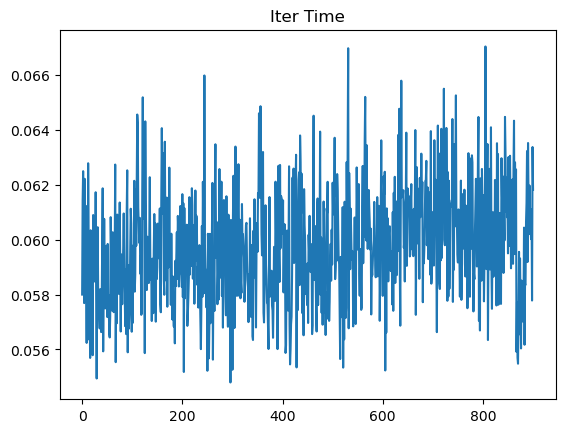

Epoch 910, Loss: 0.00322936, Time: 0.06135916709899902
Epoch 920, Loss: 0.00322619, Time: 0.05700111389160156
Epoch 930, Loss: 0.00322303, Time: 0.061305999755859375
Epoch 940, Loss: 0.00321988, Time: 0.06191205978393555
Epoch 950, Loss: 0.00321673, Time: 0.05783224105834961
Epoch 960, Loss: 0.00321359, Time: 0.059043169021606445
Epoch 970, Loss: 0.00321046, Time: 0.06265115737915039
Epoch 980, Loss: 0.00320734, Time: 0.059771060943603516
Epoch 990, Loss: 0.00320422, Time: 0.058850765228271484
Epoch 1000, Loss: 0.00320111, Time: 0.057131052017211914


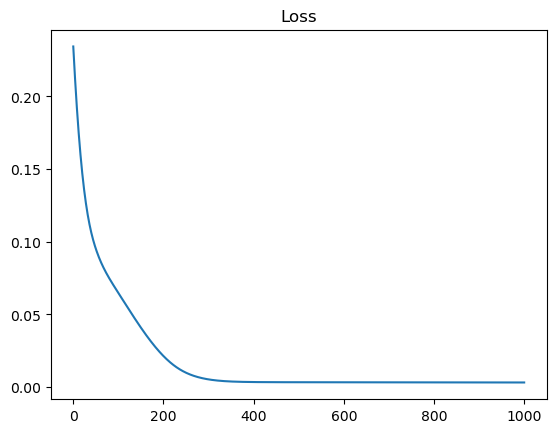

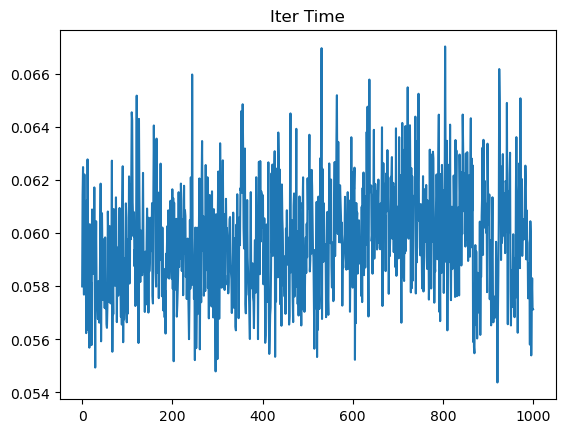

Epoch 1010, Loss: 0.00319802, Time: 0.06129121780395508
Epoch 1020, Loss: 0.00319492, Time: 0.05931210517883301
Epoch 1030, Loss: 0.00319184, Time: 0.057713985443115234
Epoch 1040, Loss: 0.00318877, Time: 0.05937004089355469


KeyboardInterrupt: 

In [40]:
%matplotlib inline
optimizer = optim.Adam(blended_mlp.parameters(), lr=0.05) #repeated in case you want to edit lr
optimizer = optim.Adam(blended_mlp.parameters(), lr=0.001) #repeated in case you want to edit lr


# Training loop
while loss > 0.0:           # and epoch<=1000:

    time_A=time.time()
    
    optimizer.zero_grad()
    output_train = blended_mlp(t_train)

    time_B=time.time()

    loss = (output_train-target_train).pow(2).sum(-1).mean()
    loss.backward()
    optimizer.step()

    this_time = time_B-time_A


    #################################

    
    times.append(this_time)
    losses.append(loss.detach())
    
    
    # Corrected indentation for if condition
    if epoch % 10 == 0:
        print(f"Epoch {epoch}, Loss: {loss.item():.8f}, Time: {this_time}")

    if epoch%100 ==0:
        plt.plot(losses)
        plt.title('Loss')
        plt.show()

        plt.plot(times)
        plt.title('Iter Time')
        plt.show()
        

    epoch += 1  # Increment epoch counter

In [41]:
show_stuff(output_train)

In [ ]:
blended_mlp.save_mlps('models/temp.pth')

In [ ]:
import importlib
import differential  # Ensure it is imported first
importlib.reload(differential)

diffmod = differential.DifferentialModule()




t = t_train
t.requires_grad=True
out = blended_mlp.forward(t)


colors = np.zeros_like(out.detach().numpy())
for i in range(out.shape[0]):
    normals = diffmod.compute_normals(out=out[i,:,:], wrt=t)
    colors[i,:,:] = (normals.detach().numpy() + 1.0)/2.0
show_f(out.detach().numpy(),colors )



In [ ]:
'''
import importlib
import differential  # Ensure it is imported first
importlib.reload(differential)

diffmod = differential.DifferentialModule()


for i in range(out.shape[0]):
    I_E, I_F, I_G = diffmod.compute_FFF(out=out[i,:,:], wrt=t)
    L,M,N = diffmod.compute_SFF(out=out[i,:,:], wrt=t)
'''

In [ ]:
import importlib
import differential  # Ensure it is imported first
importlib.reload(differential)

diffmod = differential.DifferentialModule()

all_H = torch.zeros((out.shape[0], out.shape[1]))
all_K = torch.zeros_like(all_H)
for i in range(out.shape[0]):
    H,K = diffmod.compute_curvature(out=out[i,:,:], wrt=t)
    all_H[i,:]=H.detach()
    all_K[i,:]=K.detach()

In [ ]:
from colourmappings import *

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.colorbar import ColorbarBase


cmap = plt.get_cmap('seismic')
Hmap=mapping12
Kmap=mapping12



In [ ]:
mapped_vals = Hmap(all_H)
colors = cmap(mapped_vals)[:,:,:-1] #no need for alpha channel
show_f(out.detach().numpy(),colors )

mapped_vals = Kmap(all_K)
colors = cmap(mapped_vals)[:,:,:-1] #no need for alpha channel
show_f(out.detach().numpy(),colors )

In [ ]:


# Mean Curvature Colourbar
values = np.linspace(-32, 32, 17)
transformed_values = [Hmap(val) for val in values]
fig, ax = plt.subplots()
cbar = ColorbarBase(ax, cmap=cmap, norm=Normalize(vmin=0, vmax=1))
cbar.set_ticks(transformed_values)
cbar.set_ticklabels([f'{t:.2f}' for t in values]) 
plt.title('Mean Curvature Colourbar')
plt.show()


# Gauss Curvature Colourbar
values = np.linspace(-32, 32, 17)

transformed_values = [Kmap(val) for val in values]
fig, ax = plt.subplots()
cbar = ColorbarBase(ax, cmap=cmap, norm=Normalize(vmin=0, vmax=1))
cbar.set_ticks(transformed_values)
cbar.set_ticklabels([f'{t:.2f}' for t in values])
plt.title('Gauss Curvature Colourbar')
plt.show()

In [ ]:
output_train.shape

In [ ]:
out.shape

In [ ]:
colors.dtype